In [14]:
import pandas as pd
import anndata as ad 
import scanpy as sc 
import os
import pickle as pkl 

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [15]:
paired_contrast = [
    ("Control_Young","Trained_Young"),
    ("Control_Young","Control_Old"),
    ("Control_Old","Trained_Old"),
    ("Trained_Young","Trained_Old")
]

In [16]:
design = '~condition'

In [17]:
adata = sc.read("./data/adata_filter_genes.h5ad")

In [21]:
adata

AnnData object with n_obs × n_vars = 16 × 22289
    obs: 'treatment', 'stimulation', 'Age', 'condition'
    var: 'gene_name'

Create your contrast here. First paired will ALWAYS be the reference!!

In [29]:
def create_model(
    adata,
    variable_of_interest,
    reference_level,
    test_level,
    prefix="",
    batch_name="",
    design="~condition",
    overwrite=False,
):
    # -----------------------------------------------------------
    # 1. Build output names
    # -----------------------------------------------------------
    design_name = design.replace(" ", "-")
    model_path = os.path.join(
        "./results/models/",
        f"model_{prefix}{design_name}.pkl",
    )
    excel_path = (
        f"./results/contrasts/"
        f"{prefix}{batch_name}{variable_of_interest}_"
        f"{test_level}_VS_{reference_level}.csv"
    )

    genes = adata.var.copy()

    # -----------------------------------------------------------
    # 2. Load or compute model
    # -----------------------------------------------------------
    if os.path.exists(model_path) and not overwrite:
        print(f"⚠️ Model already exists, loading: {model_path}")
        with open(model_path, "rb") as f:
            dds = pkl.load(f)

    else:
        print(f"Creating DESeq2 model for design {design}...")
        dds = DeseqDataSet(
            adata=adata,
            design=design,
            refit_cooks=True,
        )
        dds.deseq2()
        dds.vst()

        dds.plot_dispersions(
            save_path=f"./figures/QC/{prefix}dispersion_{design_name}.png"
        )

        os.makedirs("./results/models/", exist_ok=True)
        with open(model_path, "wb") as f:
            pkl.dump(dds, f)

        print(f"✅ Model saved to {model_path}")

    # -----------------------------------------------------------
    # 3. Run stats for the requested contrast
    # -----------------------------------------------------------
    print(
        f"Running DESeqStats for contrast: "
        f"{variable_of_interest} {test_level} vs {reference_level}"
    )

    stat_res = DeseqStats(
        dds,
        contrast=[variable_of_interest, test_level, reference_level],
    )
    stat_res.summary()
    df_res = stat_res.results_df
    print("HELLLO",genes)
    print(df_res)
    concat = pd.concat([genes, df_res], axis=1)
    os.makedirs("./results/contrasts/", exist_ok=True)
    concat.to_csv(excel_path, index=True,sep=';')

    print(f"📁 Results saved to {excel_path}")


Control_Young
Creating DESeq2 model for design ~condition...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 3.27 seconds.

Fitting dispersion trend curve...
... done in 0.78 seconds.

Fitting MAP dispersions...
... done in 4.20 seconds.

Fitting LFCs...
... done in 2.70 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Fitting size factors...
... done in 0.03 seconds.



Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.16 seconds.



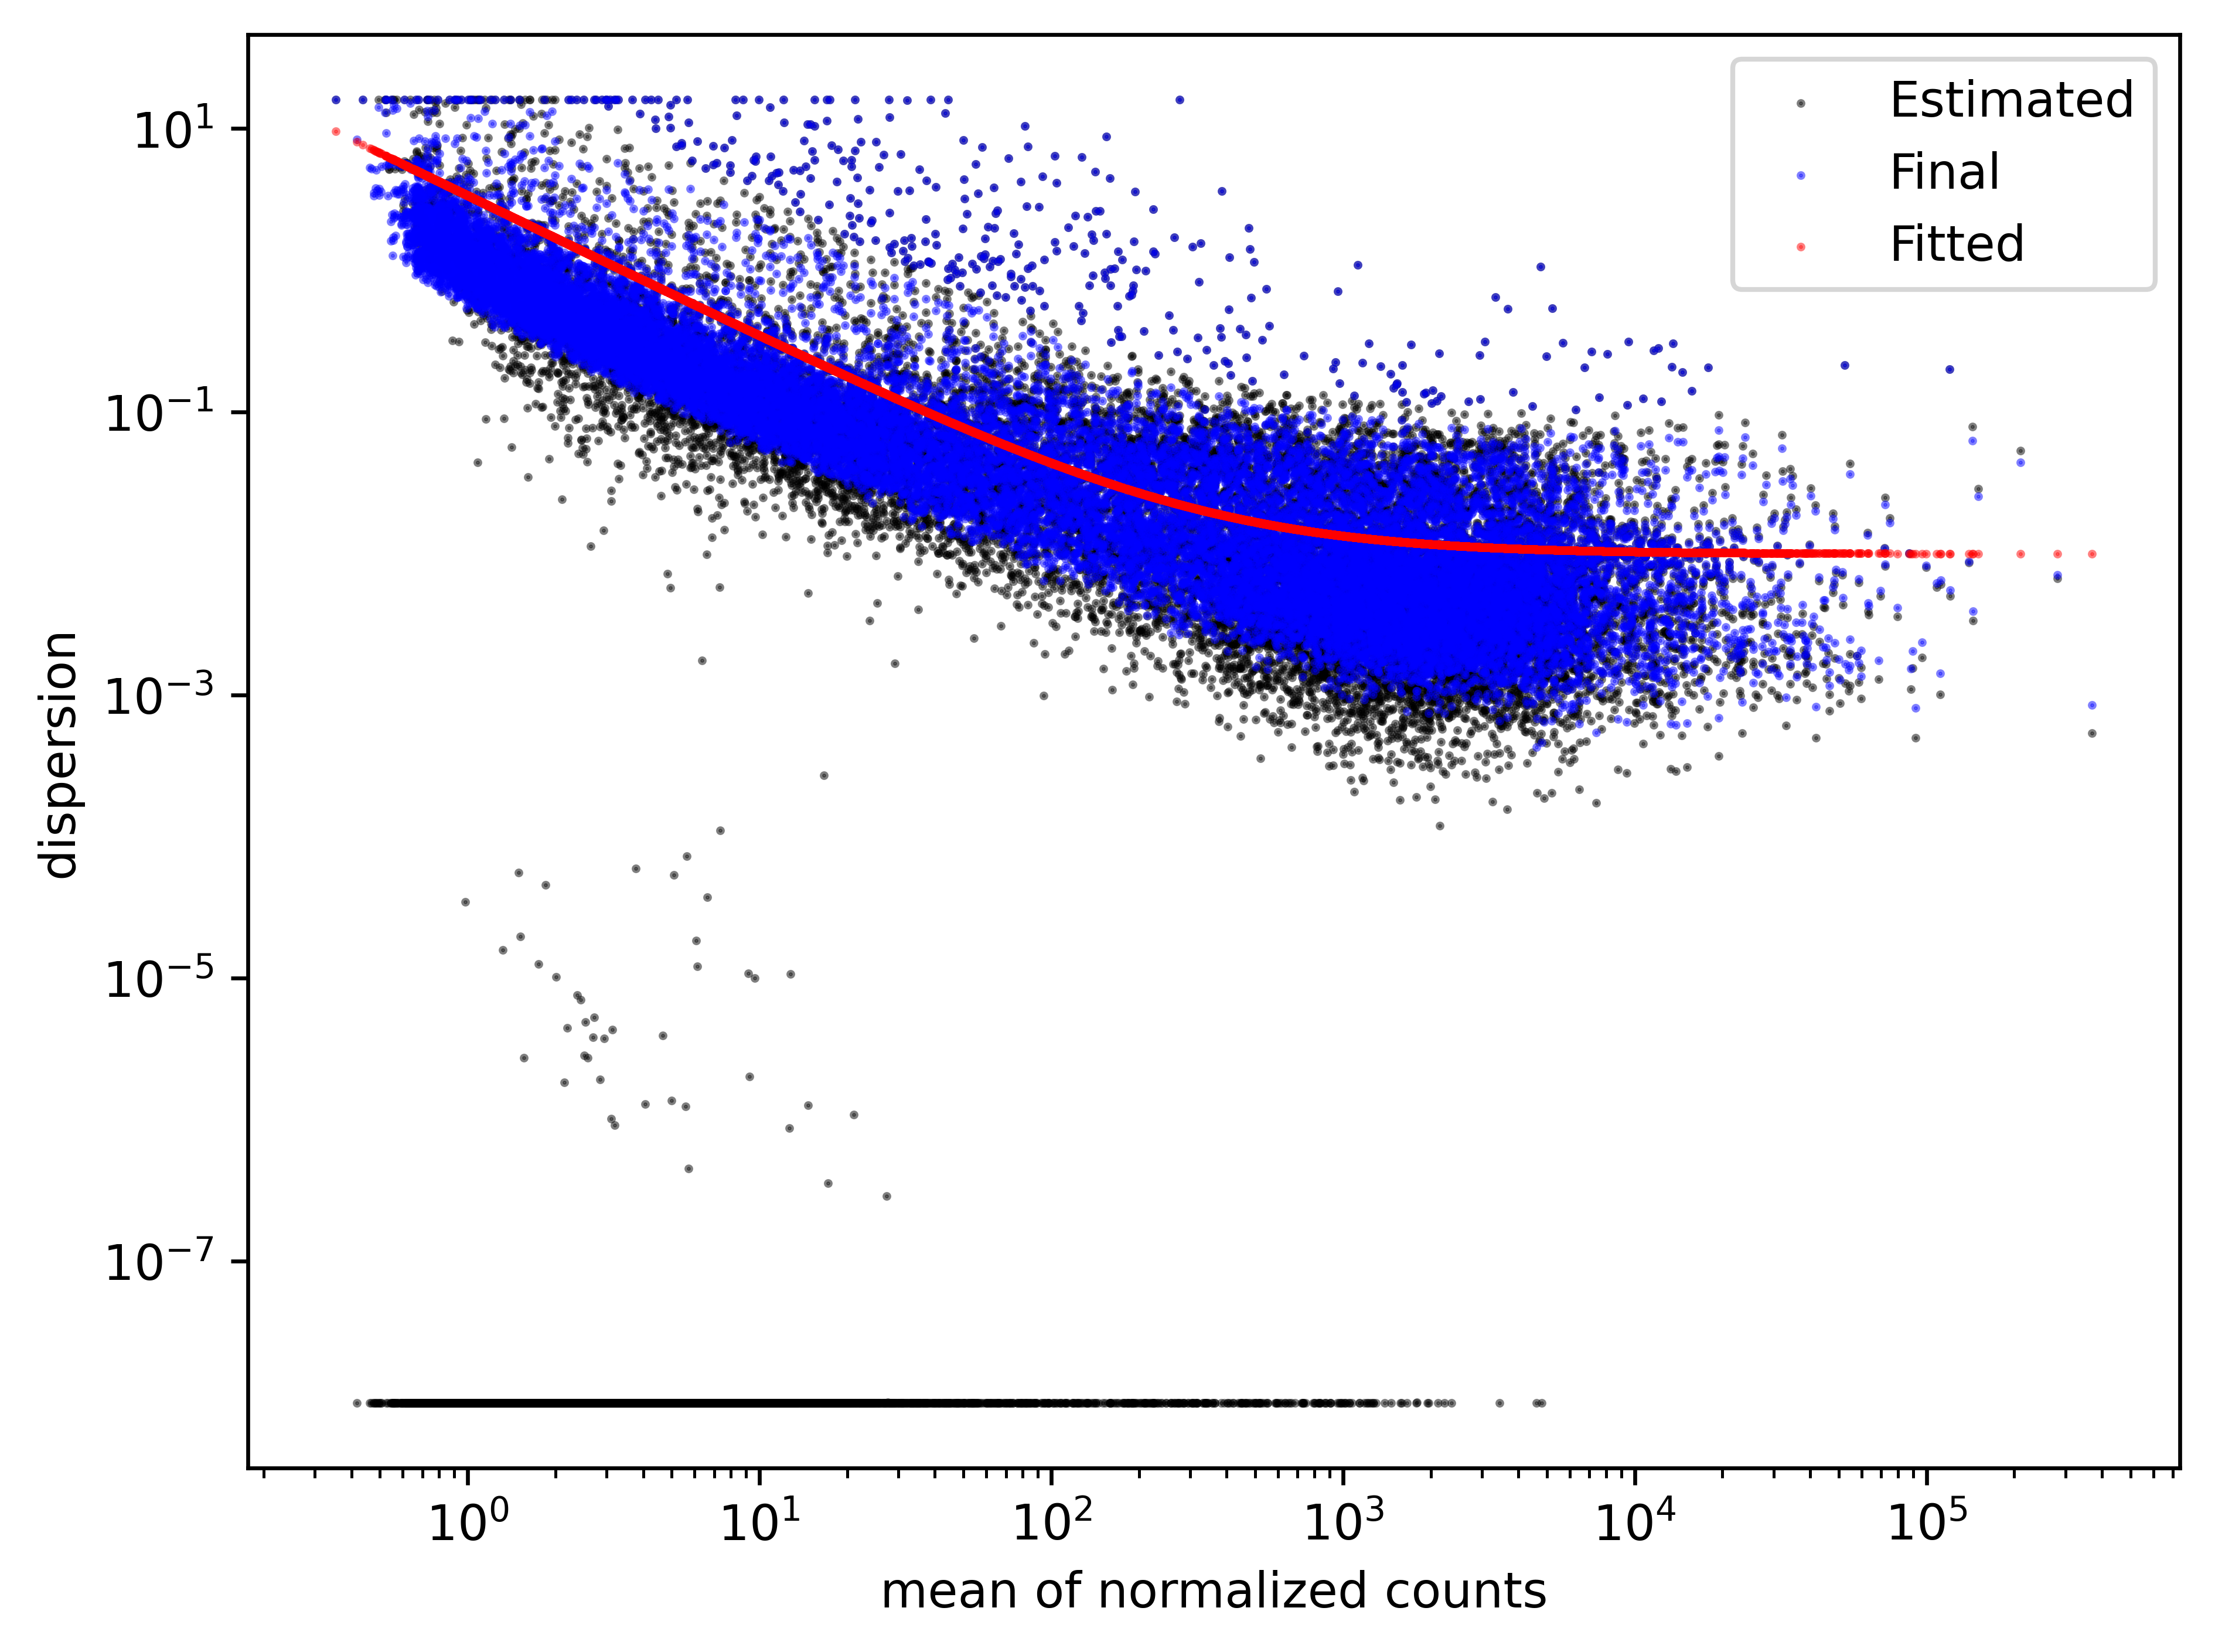

✅ Model saved to ./results/models/model_~condition.pkl
Running DESeqStats for contrast: condition Trained_Young vs Control_Young


Running Wald tests...
... done in 1.82 seconds.



Log2 fold change & Wald test p-value: condition Trained_Young vs Control_Young
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                         
ENSMUSG00000000001  6614.435806        0.071631  0.061170  1.171015  0.241593   
ENSMUSG00000000028  2677.765983       -0.053403  0.067647 -0.789444  0.429853   
ENSMUSG00000000031     3.545939        0.756689  0.707121  1.070099  0.284575   
ENSMUSG00000000037   506.453130       -0.430428  0.134007 -3.211980  0.001318   
ENSMUSG00000000056  2833.805782       -0.379488  0.161121 -2.355297  0.018508   
...                         ...             ...       ...       ...       ...   
ENSMUSG00002076556    16.984368       -0.763153  0.990746 -0.770281  0.441133   
ENSMUSG00002076601     0.616981       -0.113076  2.031281 -0.055667  0.955607   
ENSMUSG00002076665     0.485802        1.202252  2.602920  0.461886  0.644163   
ENSMUSG00002076675     0.72981

Running Wald tests...
... done in 1.86 seconds.



Log2 fold change & Wald test p-value: condition Control_Old vs Control_Young
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                         
ENSMUSG00000000001  6614.435806        0.075209  0.061264  1.227622  0.219589   
ENSMUSG00000000028  2677.765983       -0.051781  0.067851 -0.763154  0.445371   
ENSMUSG00000000031     3.545939        0.109256  0.764521  0.142908  0.886363   
ENSMUSG00000000037   506.453130       -0.380692  0.134451 -2.831449  0.004634   
ENSMUSG00000000056  2833.805782        0.078905  0.161024  0.490018  0.624121   
...                         ...             ...       ...       ...       ...   
ENSMUSG00002076556    16.984368       -0.499397  0.990155 -0.504363  0.614007   
ENSMUSG00002076601     0.616981        0.053467  2.036357  0.026256  0.979053   
ENSMUSG00002076665     0.485802       -0.620040  2.841005 -0.218247  0.827237   
ENSMUSG00002076675     0.729818 

Running Wald tests...
... done in 1.79 seconds.



Log2 fold change & Wald test p-value: condition Trained_Old vs Control_Old
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                         
ENSMUSG00000000001  6614.435806        0.127988  0.061169  2.092382  0.036404   
ENSMUSG00000000028  2677.765983       -0.168258  0.068057 -2.472314  0.013424   
ENSMUSG00000000031     3.545939        0.312199  0.732700  0.426094  0.670039   
ENSMUSG00000000037   506.453130       -0.261740  0.136071 -1.923556  0.054410   
ENSMUSG00000000056  2833.805782       -0.576188  0.161222 -3.573878  0.000352   
...                         ...             ...       ...       ...       ...   
ENSMUSG00002076556    16.984368       -1.205691  1.012169 -1.191196  0.233577   
ENSMUSG00002076601     0.616981       -1.387464  2.275338 -0.609784  0.542005   
ENSMUSG00002076665     0.485802       -0.858608  3.142827 -0.273196  0.784703   
ENSMUSG00002076675     0.729818   

Running Wald tests...
... done in 1.86 seconds.



Log2 fold change & Wald test p-value: condition Trained_Old vs Trained_Young
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                         
ENSMUSG00000000001  6614.435806        0.131566  0.061075  2.154157  0.031228   
ENSMUSG00000000028  2677.765983       -0.166635  0.067853 -2.455815  0.014057   
ENSMUSG00000000031     3.545939       -0.335233  0.672589 -0.498422  0.618187   
ENSMUSG00000000037   506.453130       -0.212003  0.135632 -1.563078  0.118034   
ENSMUSG00000000056  2833.805782       -0.117796  0.161319 -0.730205  0.465265   
...                         ...             ...       ...       ...       ...   
ENSMUSG00002076556    16.984368       -0.941936  1.012747 -0.930080  0.352330   
ENSMUSG00002076601     0.616981       -1.220922  2.270797 -0.537662  0.590810   
ENSMUSG00002076665     0.485802       -2.680900  2.929379 -0.915177  0.360099   
ENSMUSG00002076675     0.729818 

In [31]:
for ref,interest in paired_contrast:
    print(ref)
    adata_to_model = adata.copy()
    create_model(adata=adata_to_model,
                 variable_of_interest='condition',
                 reference_level=ref,
                 test_level=interest,
                 design=design)